# Predicting Employee Productivity Using Tree Models

For this guided project, we'll be using the dataset Productivity Prediction of Garment Employees. The original dataset is in the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employees)


## Data Exploration

In [1]:
# import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('../../dataset/garments_worker_productivity.csv')
df.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


In [3]:
# inspect the shape of the data
df.shape

(1197, 15)

There are 1197 observations and 15 features in the dataset

In [4]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [5]:
df.isnull().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [6]:
df['department'].value_counts()

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64

In [7]:
productivity = df[df['actual_productivity'] > 1]
productivity

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
337,1/20/2015,Quarter3,finishing,Tuesday,5,0.70,4.15,NaN,1440,0,0.0,0,0,8.0,1.033570
437,1/26/2015,Quarter4,finishing,Monday,3,0.75,3.94,NaN,1800,0,0.0,0,0,10.0,1.059621
456,1/27/2015,Quarter4,sweing,Tuesday,2,0.75,22.52,1635.0,6840,119,0.0,0,0,57.0,1.000230
457,1/27/2015,Quarter4,sweing,Tuesday,3,0.75,22.52,1299.0,6840,119,0.0,0,0,57.0,1.000230
477,1/28/2015,Quarter4,sweing,Wednesday,2,0.80,22.52,1559.0,6840,90,0.0,0,0,57.0,1.000230
478,1/28/2015,Quarter4,sweing,Wednesday,3,0.80,22.52,1350.0,6840,113,0.0,0,0,57.0,1.000230
498,1/29/2015,Quarter5,sweing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
518,1/31/2015,Quarter5,sweing,Saturday,3,0.80,22.52,1136.0,6960,113,0.0,0,0,58.0,1.000457
519,1/31/2015,Quarter5,sweing,Saturday,2,0.80,22.52,1397.0,6840,113,0.0,0,0,57.0,1.000230
542,2/1/2015,Quarter1,finishing,Sunday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,1.011562


In [8]:
print(len(productivity))

37


So, there are 37 rows with productivity greater than 1.

Now, lets explore other features.

In [9]:
df['quarter'].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44
Name: count, dtype: int64

In [10]:
df[df['quarter'] == 'Quarter5']

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
498,1/29/2015,Quarter5,sweing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
499,1/29/2015,Quarter5,finishing,Thursday,4,0.80,4.30,NaN,1200,0,0.0,0,0,10.0,0.989000
500,1/29/2015,Quarter5,sweing,Thursday,3,0.80,22.52,1287.0,6840,100,0.0,0,0,57.0,0.950186
501,1/29/2015,Quarter5,sweing,Thursday,4,0.80,22.52,1444.0,6900,88,0.0,0,0,57.5,0.900800
502,1/29/2015,Quarter5,sweing,Thursday,10,0.80,22.52,1088.0,6720,88,0.0,0,0,56.0,0.900130
503,1/29/2015,Quarter5,finishing,Thursday,6,0.50,2.90,NaN,1200,0,0.0,0,0,10.0,0.899000
504,1/29/2015,Quarter5,finishing,Thursday,8,0.65,4.15,NaN,960,0,0.0,0,0,8.0,0.877552
505,1/29/2015,Quarter5,finishing,Thursday,11,0.60,2.90,NaN,960,0,0.0,0,0,8.0,0.864583
506,1/29/2015,Quarter5,finishing,Thursday,10,0.80,3.94,NaN,1200,0,0.0,0,0,10.0,0.856950
507,1/29/2015,Quarter5,finishing,Thursday,1,0.75,3.94,NaN,1200,0,0.0,0,0,10.0,0.853667


## - There are 6 float columns, 5 integer columns, and 4 object column.
- The wip column contain `506` missing values. That's not a problem since unfinished items for products are mainly in sweing deparment.
- In department column, we are seeing two values for `finishing job` which indicate some type of error.
- From the observation in describe method, we can see that mean of actual productivity is higher i.e `0.735` than targted_productivity which stands at `0.729`.
- One more intersting observation, although the the actual productivity and target productivity has a range of 0 to 1. We can observe that's not the case here as actual productivity is showing **max** value of `1.12`.
- Interesting, there are 44 observations with quarter5 and most of their date ends with either 29 or 31 i.e is the end of the month.
Let's observe the error in department column.

## Dataset Cleaning

In [11]:
df['department'].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

So, the column has a trailing space in `finishing ` that's why it is showing two observation for finishing.
Let's fix this and remove the trailing space.

In [12]:
df['department'] = df['department'].str.strip()
df['department'].unique()

array(['sweing', 'finishing'], dtype=object)

Now let decide which column to used to fit the data.

In [13]:
df['date'].value_counts()

date
1/31/2015    24
3/11/2015    24
1/11/2015    23
1/24/2015    23
1/12/2015    23
3/10/2015    23
1/8/2015     22
1/13/2015    22
1/22/2015    22
1/10/2015    22
1/7/2015     22
3/9/2015     22
3/3/2015     22
1/5/2015     22
3/8/2015     22
1/25/2015    21
1/6/2015     21
1/4/2015     21
2/26/2015    21
2/28/2015    21
2/25/2015    21
2/18/2015    21
1/14/2015    21
1/17/2015    21
1/27/2015    21
1/28/2015    21
1/3/2015     21
3/4/2015     21
1/29/2015    20
2/19/2015    20
2/17/2015    20
3/1/2015     20
3/2/2015     20
2/22/2015    20
1/1/2015     19
2/7/2015     19
2/1/2015     19
1/21/2015    19
1/26/2015    19
1/18/2015    19
1/19/2015    19
1/15/2015    19
2/2/2015     19
2/23/2015    19
2/4/2015     19
2/3/2015     19
2/10/2015    19
2/11/2015    19
2/8/2015     19
2/15/2015    19
2/12/2015    19
3/7/2015     19
2/24/2015    19
3/5/2015     19
2/5/2015     18
2/9/2015     18
2/16/2015    18
2/14/2015    17
1/20/2015    15
Name: count, dtype: int64

We can observe that the date column only provide observation from january to march of 2015 which is not suitable here. So we will drop the date column

In [14]:
df = df.drop(['date'], axis = 1)

We will also replace the observation in quarter columns where there are `44` observations of quarter5 which mostly contain january 29th and 31th.
we will merge it with quarter4
In addition, it's unnecessary to feature the words "quarter" for every value, when we can simply use integers.

In [15]:
df.loc[df['quarter'] == 'Quarter5', 'quarter'] = 'Quarter4'
df['quarter'].value_counts()

quarter
Quarter1    360
Quarter2    335
Quarter4    292
Quarter3    210
Name: count, dtype: int64

In [16]:
df.loc[df["quarter"] == "Quarter1", "quarter"] = 1
df.loc[df["quarter"] == "Quarter2", "quarter"] = 2
df.loc[df["quarter"] == "Quarter3", "quarter"] = 3
df.loc[df["quarter"] == "Quarter4", "quarter"] = 4
df['quarter'] = df['quarter'].astype('int')
df["quarter"].value_counts()

quarter
1    360
2    335
4    292
3    210
Name: count, dtype: int64

- We will get rid of the "idle_time" & "idle_men" columns, as there are only 18 observations with non-zero values.
- We will also delete the "wip" column. It has too many empty observations.
- Finally, we will remove the "no_of_style_change" column, due to only 147 observations where there are changes. Also, they were only one or two style changes.

In [17]:
df = df.drop(['idle_time', 'idle_men', 'wip', 'no_of_style_change'], axis = 1)
df.head()

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity
0,1,sweing,Thursday,8,0.80,26.16,7080,98,59.0,0.940725
1,1,finishing,Thursday,1,0.75,3.94,960,0,8.0,0.886500
2,1,sweing,Thursday,11,0.80,11.41,3660,50,30.5,0.800570
3,1,sweing,Thursday,12,0.80,11.41,3660,50,30.5,0.800570
4,1,sweing,Thursday,6,0.80,25.90,1920,50,56.0,0.800382


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                1197 non-null   int64  
 1   department             1197 non-null   object 
 2   day                    1197 non-null   object 
 3   team                   1197 non-null   int64  
 4   targeted_productivity  1197 non-null   float64
 5   smv                    1197 non-null   float64
 6   over_time              1197 non-null   int64  
 7   incentive              1197 non-null   int64  
 8   no_of_workers          1197 non-null   float64
 9   actual_productivity    1197 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 93.6+ KB


We will convert the no_of_worker column to int datatype.
And, we will Round the actual_prouductivity column upto 2 decimal point.

In [19]:
df['no_of_workers'] = df['no_of_workers'].astype('int')
df['actual_productivity'] = round(df['actual_productivity'], 2)

since we are building a Classification Tree and not a Regression Tree, our target column "actual_productivity" must be categorical, not numerical.

To accomplish this, we will create a new column called "productive". It will feature boolean values indicating if the productivity targets were achieved for each observation in the dataset.

In [20]:
df['productive'] = df['actual_productivity'] >= df['targeted_productivity']
df.head()

,quarter,department,day,team,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity,productive
0,1,sweing,Thursday,8,0.80,26.16,7080,98,59,0.94,True
1,1,finishing,Thursday,1,0.75,3.94,960,0,8,0.89,True
2,1,sweing,Thursday,11,0.80,11.41,3660,50,30,0.80,True
3,1,sweing,Thursday,12,0.80,11.41,3660,50,30,0.80,True
4,1,sweing,Thursday,6,0.80,25.90,1920,50,56,0.80,True


We will now apply categorical encoding to the "department" column, which includes binary values. We'll transform them into booleans:

In [21]:
df['department'] = df['department'].replace({'sweing':1, 'finishing':0})
df.rename(columns = {'department':'dept_sewing'}, inplace = True)
df.head(10)

/tmp/ipykernel_1076/3674707769.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['department'] = df['department'].replace({'sweing':1, 'finishing':0})


,quarter,dept_sewing,day,team,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity,productive
0,1,1,Thursday,8,0.80,26.16,7080,98,59,0.94,True
1,1,0,Thursday,1,0.75,3.94,960,0,8,0.89,True
2,1,1,Thursday,11,0.80,11.41,3660,50,30,0.80,True
3,1,1,Thursday,12,0.80,11.41,3660,50,30,0.80,True
4,1,1,Thursday,6,0.80,25.90,1920,50,56,0.80,True
5,1,1,Thursday,7,0.80,25.90,6720,38,56,0.80,True
6,1,0,Thursday,2,0.75,3.94,960,0,8,0.76,True
7,1,1,Thursday,3,0.75,28.08,6900,45,57,0.75,True
8,1,1,Thursday,2,0.75,19.87,6000,34,55,0.75,True
9,1,1,Thursday,1,0.75,28.08,6900,45,57,0.75,True


For the "quarter" column, we will use "dummies", because if we leave the numbers as they currently are, the Decision Tree would believe that quarter 4 is greater than quarter 1, for example. 

The following code creates the dummies and also removes the original "quarter" column. The prefix parameter adds a "q_" prefix to all columns, so we can easily identify which ones are the dummies. Hence, the result will be to add four new columns to our dataset: "q_1", "q_2", "q_3" and "q_4".

In [22]:
df = pd.concat([df, pd.get_dummies(df['quarter'], prefix = 'q').astype('int')], axis = 1)
df = df.drop('quarter', axis = 1)
df.sample(10, random_state = 14)

,dept_sewing,day,team,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4
959,0,Thursday,10,0.70,2.90,3360,0,8,0.41,False,0,0,0,1
464,0,Tuesday,8,0.65,3.94,960,0,8,0.85,True,0,0,0,1
672,1,Sunday,7,0.70,24.26,6960,0,58,0.36,False,0,1,0,0
321,1,Monday,6,0.80,11.41,4380,50,31,0.80,True,0,0,1,0
282,0,Saturday,9,0.80,3.94,1800,0,10,0.83,True,0,0,1,0
307,1,Sunday,10,0.70,22.52,10080,40,56,0.70,True,0,0,1,0
609,0,Wednesday,9,0.75,3.94,960,0,8,0.76,True,1,0,0,0
1123,1,Sunday,8,0.60,30.48,6720,0,56,0.60,True,0,1,0,0
877,1,Sunday,9,0.70,18.79,3240,30,57,0.63,False,0,0,0,1
950,1,Thursday,3,0.75,29.40,6840,45,57,0.75,True,0,0,0,1


Let's now repeat this process for the "day" column. 

In [23]:
df = pd.concat([df, pd.get_dummies(df['day'], prefix = None).astype('int')], axis = 1)
df = df.drop('day', axis = 1)
df.sample(10, random_state = 14)

,dept_sewing,team,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity,productive,q_1,q_2,q_3,q_4,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
959,0,10,0.70,2.90,3360,0,8,0.41,False,0,0,0,1,0,0,0,1,0,0
464,0,8,0.65,3.94,960,0,8,0.85,True,0,0,0,1,0,0,0,0,1,0
672,1,7,0.70,24.26,6960,0,58,0.36,False,0,1,0,0,0,0,1,0,0,0
321,1,6,0.80,11.41,4380,50,31,0.80,True,0,0,1,0,1,0,0,0,0,0
282,0,9,0.80,3.94,1800,0,10,0.83,True,0,0,1,0,0,1,0,0,0,0
307,1,10,0.70,22.52,10080,40,56,0.70,True,0,0,1,0,0,0,1,0,0,0
609,0,9,0.75,3.94,960,0,8,0.76,True,1,0,0,0,0,0,0,0,0,1
1123,1,8,0.60,30.48,6720,0,56,0.60,True,0,1,0,0,0,0,1,0,0,0
877,1,9,0.70,18.79,3240,30,57,0.63,False,0,0,0,1,0,0,1,0,0,0
950,1,3,0.75,29.40,6840,45,57,0.75,True,0,0,0,1,0,0,0,1,0,0


The "team" column will also receive the same treatment. Given that there are 12 teams, these dummies will constitute the group with the highest number of added columns. In other words, we will be adding 12 columns to our dataset because of this transformation process in particular.

In [24]:
df = pd.concat([df, pd.get_dummies(df['team'], prefix = 'team').astype('int')], axis = 1)
df = df.drop('team', axis = 1)
df.sample(10, random_state = 14)

,dept_sewing,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity,productive,q_1,q_2,...,team_3,team_4,team_5,team_6,team_7,team_8,team_9,team_10,team_11,team_12
959,0,0.70,2.90,3360,0,8,0.41,False,0,0,...,0,0,0,0,0,0,0,1,0,0
464,0,0.65,3.94,960,0,8,0.85,True,0,0,...,0,0,0,0,0,1,0,0,0,0
672,1,0.70,24.26,6960,0,58,0.36,False,0,1,...,0,0,0,0,1,0,0,0,0,0
321,1,0.80,11.41,4380,50,31,0.80,True,0,0,...,0,0,0,1,0,0,0,0,0,0
282,0,0.80,3.94,1800,0,10,0.83,True,0,0,...,0,0,0,0,0,0,1,0,0,0
307,1,0.70,22.52,10080,40,56,0.70,True,0,0,...,0,0,0,0,0,0,0,1,0,0
609,0,0.75,3.94,960,0,8,0.76,True,1,0,...,0,0,0,0,0,0,1,0,0,0
1123,1,0.60,30.48,6720,0,56,0.60,True,0,1,...,0,0,0,0,0,1,0,0,0,0
877,1,0.70,18.79,3240,30,57,0.63,False,0,0,...,0,0,0,0,0,0,1,0,0,0
950,1,0.75,29.40,6840,45,57,0.75,True,0,0,...,1,0,0,0,0,0,0,0,0,0


## Building the Tree

Now that the data was properly adapted for use in scikit-learn, we're ready to start building our decision tree.

To ensure that the visualization of our Tree is legible and to avoid overfitting, we set a "max_depth" of 3 so that the Tree only has 3 levels.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = df.drop(['actual_productivity','productive'], axis = 1)
y = df['productive']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,shuffle = True, random_state = 42)
model = DecisionTreeClassifier(max_depth = 3,
                               random_state = 42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy:", round(accuracy_score(y_test,y_pred), 2))

Accuracy: 0.85


## Visualizing and Evaluating the Tree

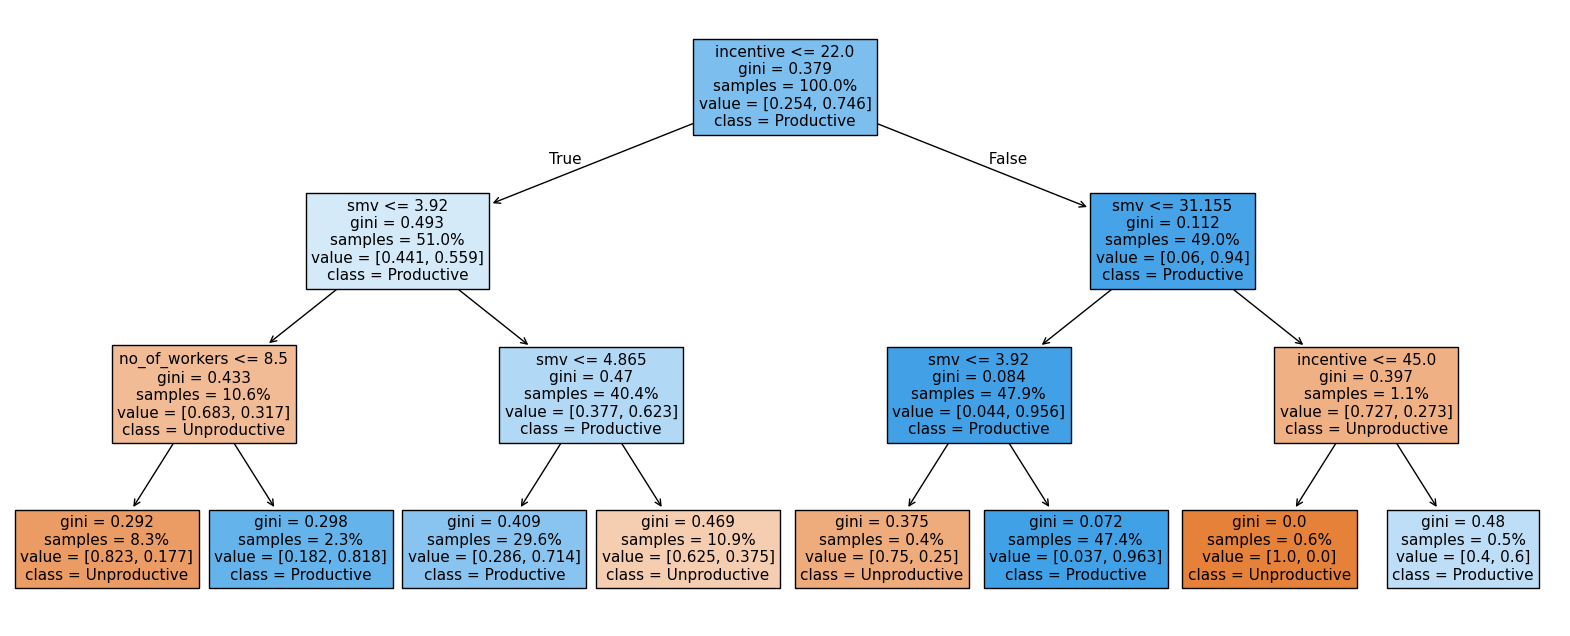

In [27]:
# Setting plot size

plt.figure(figsize = [20.0, 8.0])

# Plotting the tree with some specific parameters

_ = plot_tree(model, 
              feature_names = X.columns, 
              class_names = ["Unproductive", "Productive"],
              filled = True, 
              rounded = False, 
              proportion = True, 
              fontsize = 11) 

We can see here that the most significant columns turned out to be "incentive" and "smv" (Standard Minute Value, or the allocated time for a task). All the splits, except one, used these columns to progressively divide the dataset into more homogeneous subsets.

It's important to remember that we pruned the tree when we instantiated the model. We restricted it to only feature a maximum depth of three levels to avoiding overfitting. If we hadn't, it's likely we would've seen other columns further dividing the dataset.

Let's use the model on a hypothetical observation which has an "incentive" of 24 and a "smv" of 5. You don't actually need any code to do this, as you can use the tree visually by following the branches to reach the leaf containing the prediction.

Since the "incentive" is greater than 22, 24 <= 22 evaluates to False at the root node and so we follow the path to the right (False splits always go to the right.) Since the "smv" is less than 31.155, 5 <= 31.155 evaluates to True at the child node below the root and so we follow the path to the left (True splits always go to the left.) In the final split before the leaf, since the "smv" is greater than 3.92, 5 <= 3.92 evaluates to False and so we follow the path to the right where we reach the final leaf node, which happens to feature a "Productive" class. 

To summarize, all this means that an observation with those characteristics would be predicted as "Productive" by the Decision Tree.

In [28]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
confusion_matrix(y_test, y_pred)

array([[ 39,  20],
       [ 16, 165]])

In [29]:
print("Precision:", round(precision_score(y_test, y_pred), 2))
print("Recall:", round(recall_score(y_test, y_pred), 2))
print("F1_score:", round(f1_score(y_test, y_pred), 2))
print("Accuracy:", round(accuracy_score(y_test,y_pred), 2))

Precision: 0.89
Recall: 0.91
F1_score: 0.9
Accuracy: 0.85


We also have another option to evaluate our tree: **Cross Validation**. It divides the dataset into blocks/folds (the number of folds is determined by the "cv" parameter). Then it creates that many copies of the dataset where each copy will have a different segment of observations compared to the test set. 

This is a practical way to ensure that we didn't get the original accuracy score by pure chance by comparing it with several other possible results.

In [31]:
from sklearn.model_selection import cross_val_score

cross_scores = cross_val_score(model, X, y, cv = 10)
print("Cross Validation Accuracy Scores:", cross_scores.round(2)) 
print("Mean Cross Validation Score:", cross_scores.mean().round(2))

Cross Validation Accuracy Scores: [0.85 0.88 0.81 0.87 0.87 0.82 0.72 0.76 0.84 0.79]
Mean Cross Validation Score: 0.82


As we can see, after double checking with Cross Validate, we're still getting impressive metrics. This is excellent!

## Explaining the Tree

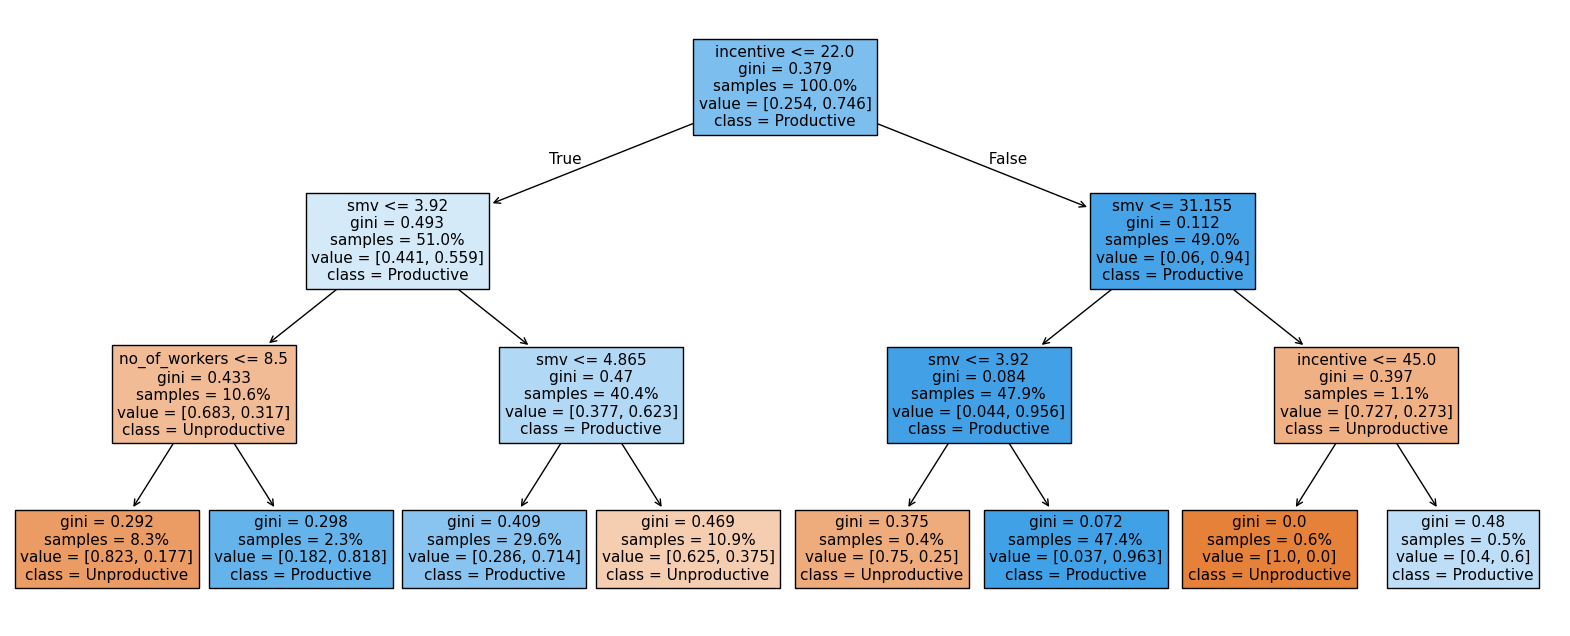

In [32]:
plt.figure(figsize = [20.0, 8.0])

_ = plot_tree(model, 
              feature_names = X.columns, 
              class_names = ["Unproductive", "Productive"],
              filled = True, 
              rounded = False, 
              proportion = True, 
              fontsize = 11) 

"The graphic above was created using predictions produced by the algorithm we implemented — a Decision Tree. We chose this algorithm because, despite how intimidating the graphic appears to be, we'll have you interpreting the results in just a few minutes!

The graphic illustrates which aspects of the factory are best at predicting if a team will be productive or not. When we say aspects, we mean variables like the date, department, team number, etc. In our case, we discovered that the "incentive" and the "smv" variables were the ones with the greatest influence on the final prediction. To provide context, the "incentive" variable represents the amount of financial incentive offered to motivate a particular course of action. The "smv" (Standard Minute Value) variable represents the time allocated for a specific task.

How do we know that these two variables are the most predictive? We know this because of the information included in the square boxes in the graphic! For example, if we focus on the top part of each box, we will see that those two variables are the ones that appear most frequently. In fact, there is only a single exception in the lower left of the graphic where the variable "number of workers" appears at the top.

You may be wondering why the algorithm is called a Decision Tree. Well, you can think of the graphic as an inverted tree with the top box, called the "root", representing the most predictive feature and the boxes at the bottom, called the "leaves", which provide the predictions. These final boxes (leaves) are the ones that tell us whether a team in a specific department was productive or not. The prediction is shown in the "class" component at the bottom of the box. Keep in mind, even though all boxes feature a "class" component, we are only interested in the classes found in a leaf, not before.

**"But how do I know which path to take from the top box to the final ones?" you might ask. Good question! Basically, we need to use the thresholds associated with every variable at the top of every square box. We have to compare our inputs with those thresholds – starting from the root – until we reach the leaves at the bottom.** When we say "input" we are referring to the corresponding "incentives" and "smv" values for a particular team. We can obtain these values from any date we choose in the dataset or we can select the values ourselves to test hypothetical situations. This is excellent for us since it means we can use the Decision Tree to predict the outcome for future and/or hypothetical scenarios so long as we have their respective incentive and SMV values.

**We get it, that last part was a bit overwhelming, so to show you how all this works, let's use an example:** a fictional date where the "incentive" is 22 and "smv" is 4.44 to predict if a team will be productive or not under these conditions. Starting from the root, we see that our first comparison will be 22 <= 22 when we **substitute "incentive" for 22**.

So, is 22 less than or equal to 22? Yes! Since the assertion is True, we follow the arrow to the lower left box. This is a universal rule of Decision Trees: if the assertion is True, we continue to the left; otherwise, if it's False, we continue to the right. 

True = Left. False = Right.

Now we repeat the process for the rest of the boxes. We apply the same approach to the next box, which has the comparrison 4.44 <= 3.92 after **we substitute "smv" for 4.44**.

So, is 4.44 less than or equal to 3.92? No! Since the assertion is False, we follow the arrow to the lower right box. Again, **after substituting "smv" for 4.44** in that box, our final comparison is 4.44 <= 4.865.

So, is 4.44 less than or equal to 4.865? Yes! Since the assertion is True, we follow the arrow to the final lower left box, the leaf, which predicts the team will be "Productive". In other words, if we have a team with an "incentive" of 22 and a SMV of 4.44, it will be a productive team!

To summarize, the Decision Tree not only told us which variables have the strongest predictive power ("incentive" and "smv"), but it also allows us to make predictions using values of our own choosing. This is the power of Decision Trees! Any questions?"

## Using Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(oob_score = True, random_state = 42)
forest.fit(X_train,y_train)
y_pred = forest.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy',round(accuracy,2))

Accuracy 0.82


Let's also check the Out of Bag Score. As a reminder, when Random Forest generates training subsets for every individual Tree, it leaves out some observations of the dataset, and if we activate the OOB Score then those observations will be used as test subsets.

In [36]:
print("Out Of Bag Score:", round(forest.oob_score_, 2))

Out Of Bag Score: 0.84


Since the evaluation metrics of our Random Forest are similar to the scores of our Decision Tree, we can be confident about our results! 

Because of their tendency to overfit the data, it's always considered good practice to double-check Trees with a Random Forest.

## Conclusion

After completing a project, it is helpful to reflect on and highlight important aspects of the entire process to help solidify our learning.

- It's critically important to understand the data we're working with. Keeping the dataset description close at hand and referring to it often can help avoid confusion! Faulty assumptions early on can easily lead us to confusing results later on.

- As part of the Exploratory Data Analysis phase, always ensure the consistency and validity of the data. It's vital to identify any outliers, incorrect data, or any other error that can compromise the integrity of the data.

- Exercise good judgement when selecting the columns to train the model while making the necessary transformations (like a correct encoding) to ensure the model interprets the data correctly.

- Take all the time you need during the Data Cleaning phase to ensure there are no incorrect observations that could potentially foul the model during training. 

- When creating the Decision Tree algorithm, under no circumstances should we skip the evaluation phase! It can often provide us with clues about which hyperparameters to add or change when optimizing the model later on.

- It's good practice to double check our Trees with the Random Forest technique.

- Finally, if we're going to explain our findings to an audience, it pays to come prepared. While it's true that Decision Trees are easier to explain than other machine learning algorithms, it is still a machine learning algorithm and non-technical audiences will naturally be aprehensive!

You may have noticed that we made sure to comply with all these points throughout this project. This explains why we were able to create a highly accurate Decision Tree. While the steps that involved the *scikit-learn* library were of vital importance, we should never underestimate the value of all the preparation we did prior.